# RetailPulse – Exploratory Data Analysis

## Objective

Analyze cleaned retail transaction data to identify:

- Sales performance
- Revenue trends
- Product performance
- Customer behavior
- Geographic performance
- Transaction patterns
- Cancellation behavior
- Business opportunities

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### Load cleaned data

In [4]:
CLEANED_DIR = Path("../data/cleaned")

print("Cleaned directory:", CLEANED_DIR)
print("Directory exists:", CLEANED_DIR.exists())

Cleaned directory: ..\data\cleaned
Directory exists: True


In [5]:
sales = pd.read_csv(
    CLEANED_DIR / "retail_sales.csv"
)

customer = pd.read_csv(
    CLEANED_DIR / "retail_customer_analysis.csv"
)

master = pd.read_csv(
    CLEANED_DIR / "retail_master_cleaned.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [12]:
# Convert InvoiceDate back to datetime after loading CSV files

sales["InvoiceDate"] = pd.to_datetime(
    sales["InvoiceDate"],
    errors="coerce"
)

customer["InvoiceDate"] = pd.to_datetime(
    customer["InvoiceDate"],
    errors="coerce"
)

master["InvoiceDate"] = pd.to_datetime(
    master["InvoiceDate"],
    errors="coerce"
)

print("InvoiceDate converted successfully.")
print("Sales InvoiceDate type:", sales["InvoiceDate"].dtype)

InvoiceDate converted successfully.
Sales InvoiceDate type: datetime64[ns]


In [13]:
print(
    "Invalid sales dates:",
    sales["InvoiceDate"].isna().sum()
)

Invalid sales dates: 0


### Verify datasets

In [6]:
print("Sales:", sales.shape)
print("Customer:", customer.shape)
print("Master:", master.shape)

Sales: (779425, 17)
Customer: (779425, 17)
Master: (797885, 17)


### Basic sales KPIs

In [9]:
total_revenue = sales["Revenue"].sum()

total_transactions = sales["Invoice"].nunique()

total_products = sales["StockCode"].nunique()

total_customers = sales["Customer_ID"].nunique()

total_quantity = sales["Quantity"].sum()

average_order_value = (
    total_revenue / total_transactions
)

In [10]:
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Order Value: {average_order_value:,.2f}")

Total Revenue: 17,374,804.27
Total Transactions: 36,969
Total Products: 4,631
Total Customers: 5,878
Total Quantity Sold: 10,513,952
Average Order Value: 469.98


### Revenue by month

In [14]:
monthly_sales = (
    sales
    .set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales

,InvoiceDate,Revenue
0,2009-12-31,683504.010
1,2010-01-31,555802.672
2,2010-02-28,504558.956
3,2010-03-31,696978.471
4,2010-04-30,591982.002
5,2010-05-31,597833.380
6,2010-06-30,636371.130
7,2010-07-31,589736.170
8,2010-08-31,602224.600
9,2010-09-30,829013.951


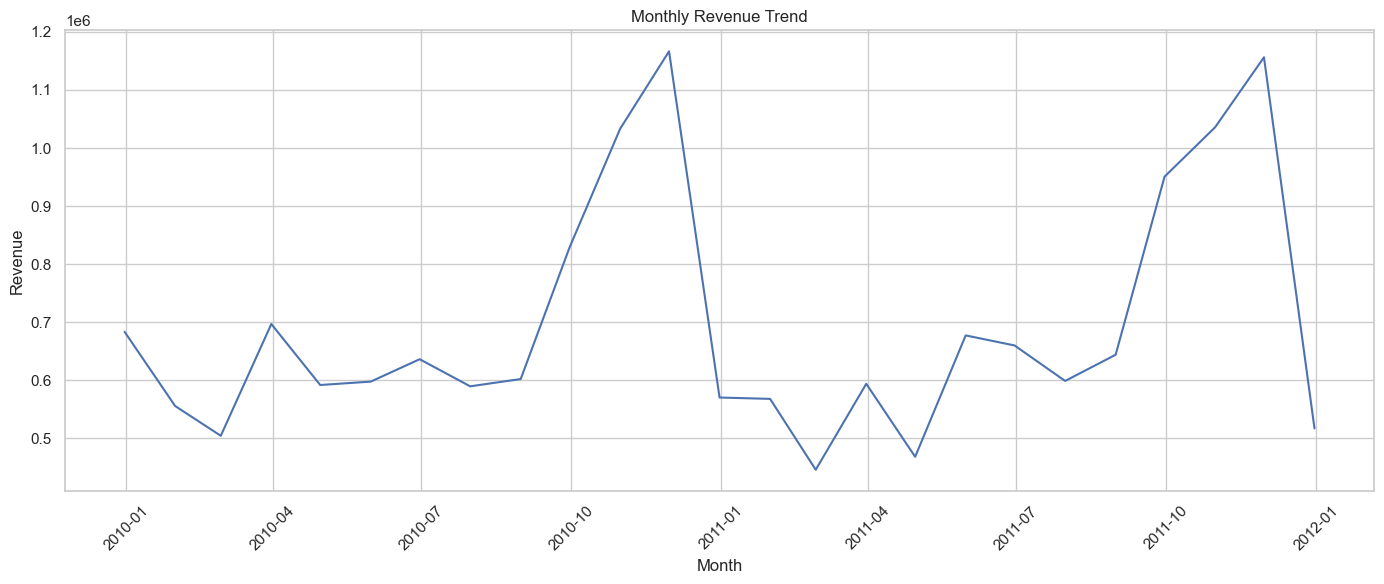

In [15]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="InvoiceDate",
    y="Revenue"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business question

### Is revenue increasing, decreasing, or showing seasonal behavior?

### Monthly Orders

In [17]:
monthly_orders = (
    sales
    .set_index("InvoiceDate")
    .resample("ME")["Invoice"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders

,InvoiceDate,Orders
0,2009-12-31,1512
1,2010-01-31,1011
2,2010-02-28,1104
3,2010-03-31,1524
4,2010-04-30,1329
5,2010-05-31,1377
6,2010-06-30,1497
7,2010-07-31,1381
8,2010-08-31,1293
9,2010-09-30,1689


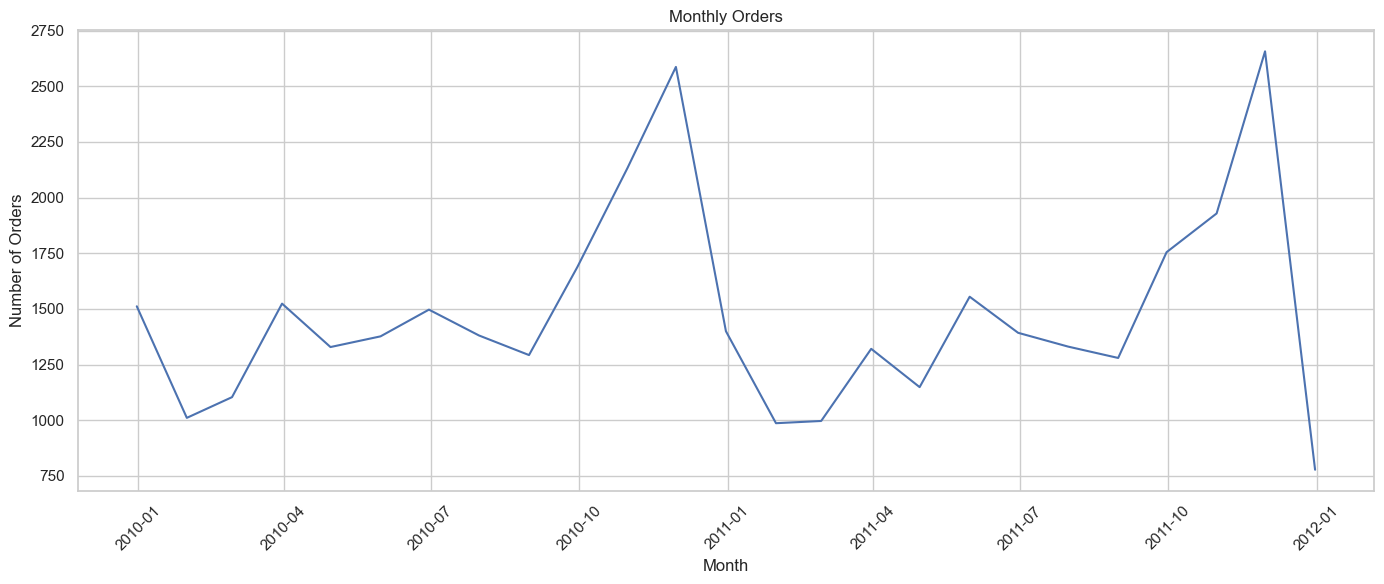

In [18]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_orders,
    x="InvoiceDate",
    y="Orders"
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top products by revenue

In [19]:
top_products = (
    sales
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(20)
)

top_products

,StockCode,Description,Revenue
1862,22423,REGENCY CAKESTAND 3 TIER,277656.25
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,247048.01
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
5309,M,Manual,151777.67
4725,85099B,JUMBO BAG RED RETROSPOT,134307.44
5311,POST,POSTAGE,124648.04
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,124351.86
3627,47566,PARTY BUNTING,103283.38
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
1449,22086,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18


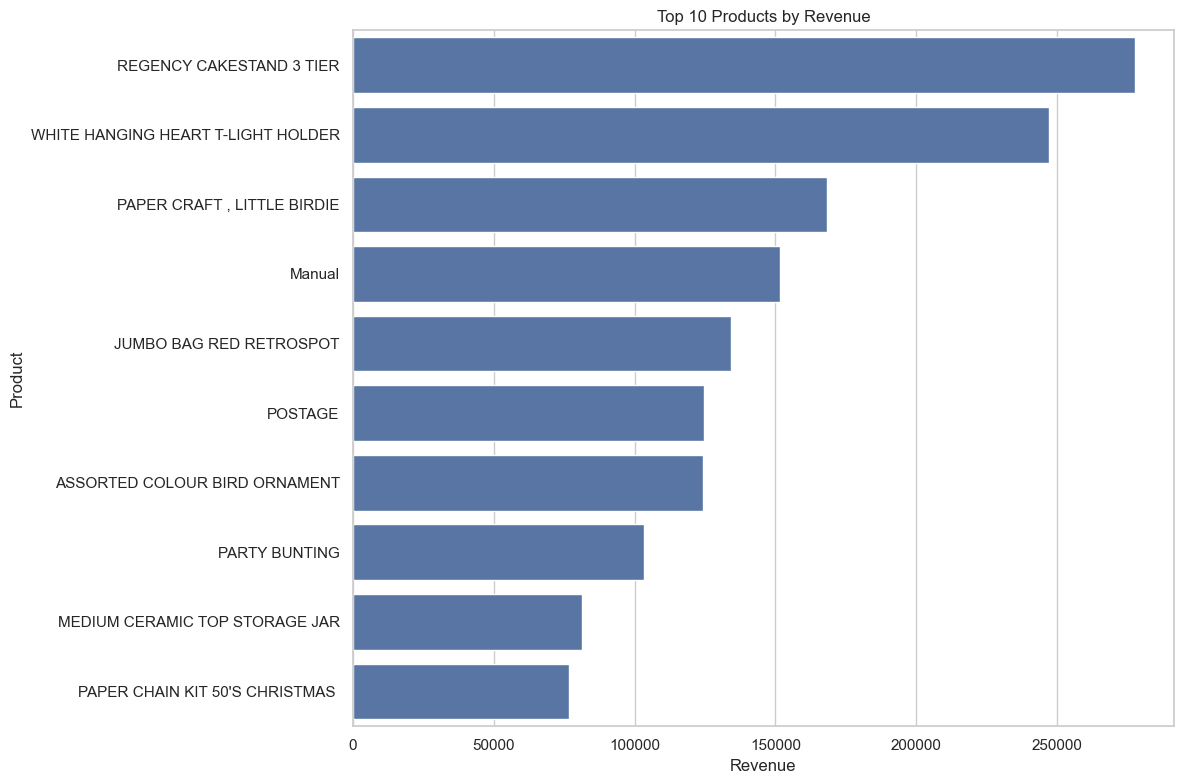

In [20]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_products.head(10),
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Top products by quantity

In [21]:
top_quantity_products = (
    sales
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Quantity"]
    .sum()
    .reset_index()
    .sort_values(
        "Quantity",
        ascending=False
    )
    .head(20)
)

top_quantity_products

,StockCode,Description,Quantity
4031,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,105185
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,91757
3283,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,78234
2781,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
4725,85099B,JUMBO BAG RED RETROSPOT,74224
115,17003,BROCADE RING PURSE,70082
1357,21977,PACK OF 60 PINK PAISLEY CAKE CASES,54592
4595,84991,60 TEATIME FAIRY CAKE CASES,52828
658,21212,PACK OF 72 RETRO SPOT CAKE CASES,45129


## This answers:

Which products sell the highest quantity?

Notice that highest quantity ≠ highest revenue.
That's an important business insight.

## Country revenue

In [22]:
country_revenue = (
    sales
    .groupby("Country")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
)

country_revenue.head(15)

,Country,Revenue
38,United Kingdom,1.438923e+07
10,EIRE,6.165705e+05
24,Netherlands,5.540381e+05
14,Germany,4.250197e+05
13,France,3.487690e+05
0,Australia,1.692835e+05
32,Spain,1.083325e+05
34,Switzerland,1.000619e+05
33,Sweden,9.151582e+04
9,Denmark,6.858069e+04


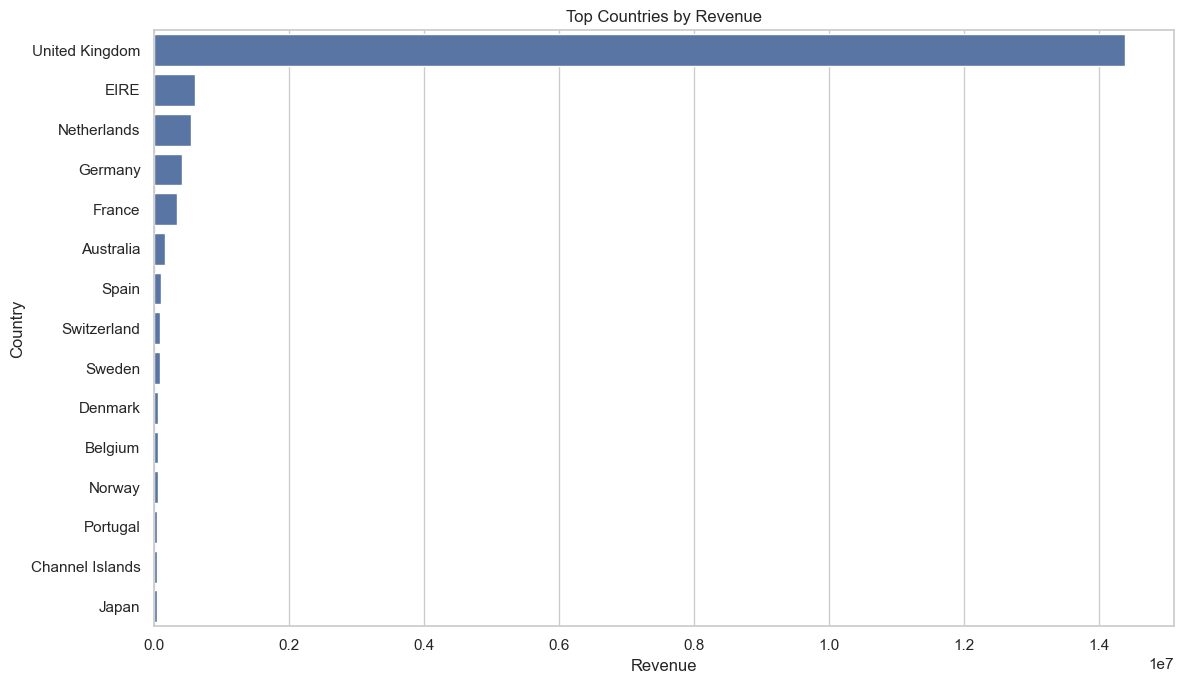

In [23]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_revenue.head(15),
    x="Revenue",
    y="Country"
)

plt.title("Top Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## Customer revenue

In [25]:
customer_revenue = (
    customer
    .groupby("Customer_ID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values(
        "Revenue",
        ascending=False
    )
)

customer_revenue.head(20)

,Customer_ID,Revenue
5692,18102,580987.04
2277,14646,528602.52
1789,14156,313437.62
2538,14911,291420.81
5050,17450,244784.25
1331,13694,195640.69
5109,17511,172132.87
4061,16446,168472.50
4295,16684,147142.77
68,12415,144458.37


## Top customers

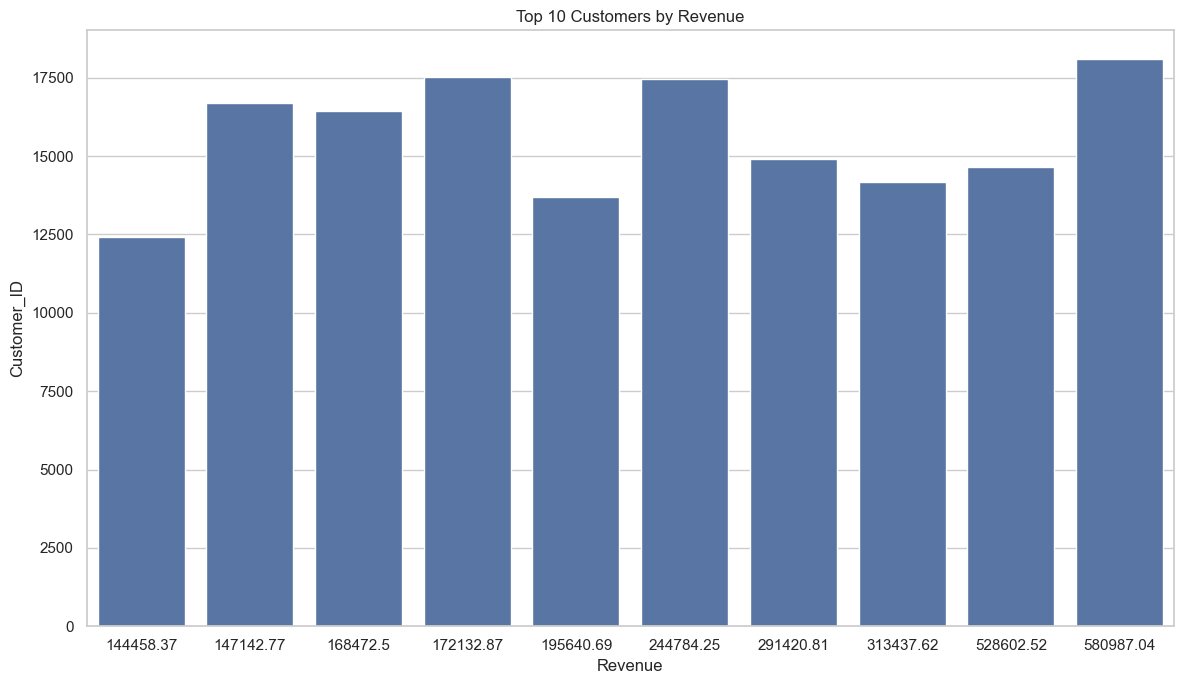

In [27]:
top_customers = customer_revenue.head(20)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_customers.head(10),
    x="Revenue",
    y="Customer_ID"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer_ID")

plt.tight_layout()
plt.show()

## Orders per customer

In [29]:
orders_per_customer = (
    customer
    .groupby("Customer_ID")["Invoice"]
    .nunique()
    .reset_index(name="Orders")
)

orders_per_customer.head()

,Customer_ID,Orders
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1


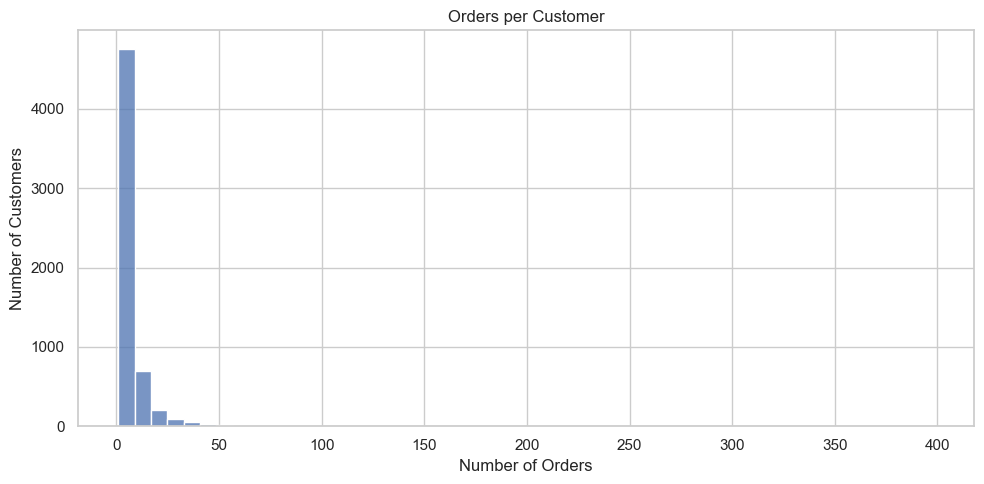

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=orders_per_customer,
    x="Orders",
    bins=50
)

plt.title("Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Customer revenue distribution

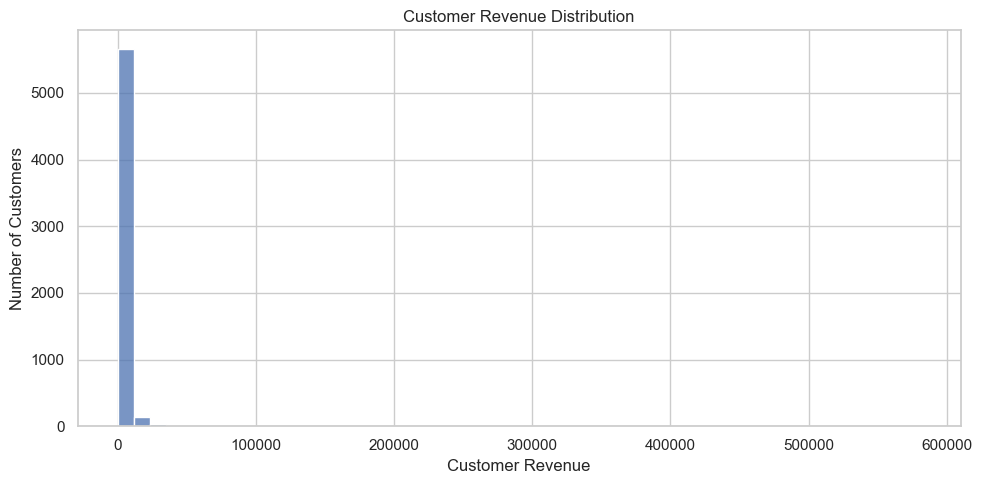

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=customer_revenue,
    x="Revenue",
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

You may notice a highly skewed distribution.

That is normal for customer transaction data.

## Day-of-week analysis

In [34]:
sales["DayName"] = sales["InvoiceDate"].dt.day_name()

In [35]:
day_sales = (
    sales
    .groupby("DayName")["Revenue"]
    .sum()
    .reset_index()
)

In [36]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales["DayName"] = pd.Categorical(
    day_sales["DayName"],
    categories=day_order,
    ordered=True
)

day_sales = day_sales.sort_values("DayName")

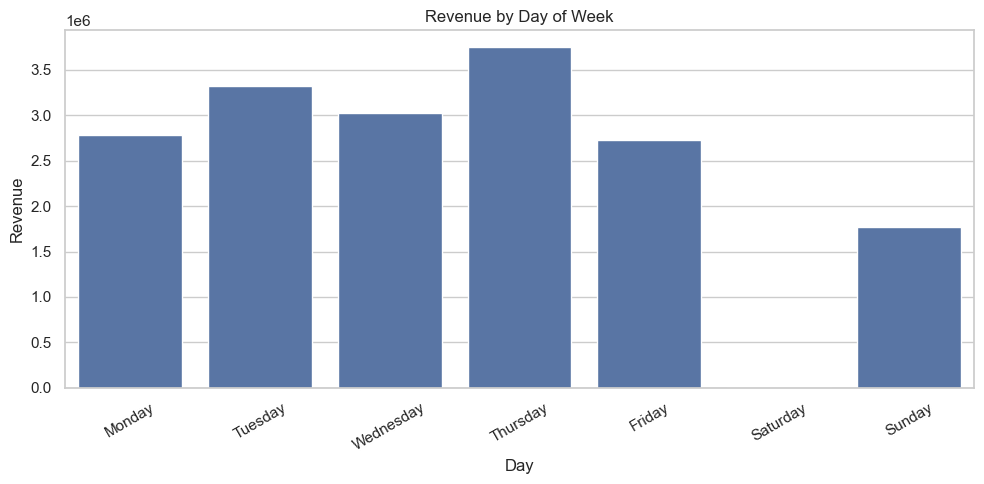

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=day_sales,
    x="DayName",
    y="Revenue"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Hourly sales

In [38]:
sales["Hour"] = sales["InvoiceDate"].dt.hour

hourly_sales = (
    sales
    .groupby("Hour")["Revenue"]
    .sum()
    .reset_index()
)

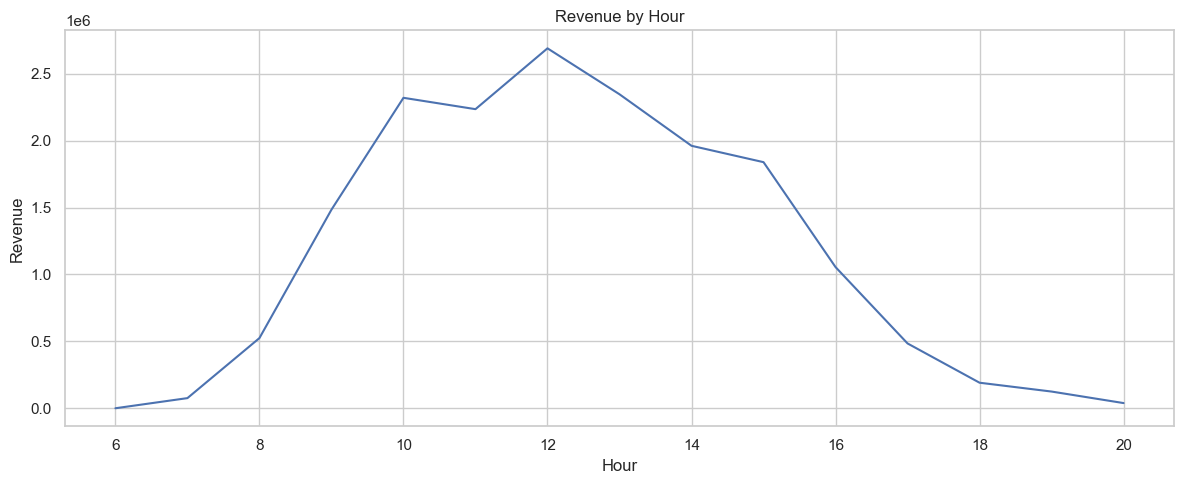

In [39]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_sales,
    x="Hour",
    y="Revenue"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Cancellation analysis

In [40]:
master["TransactionType"].value_counts()

TransactionType
Sale         779495
Cancelled     18390
Name: count, dtype: int64

In [41]:
cancellation_revenue = master.loc[
    master["TransactionType"] == "Cancelled",
    "Revenue"
].sum()

print(
    f"Cancellation transaction value: "
    f"{cancellation_revenue:,.2f}"
)

Cancellation transaction value: -1,084,812.98


## Cancellation by product

In [42]:
cancelled_products = (
    master[
        master["TransactionType"] == "Cancelled"
    ]
    .groupby("Description")["Quantity"]
    .sum()
    .reset_index()
    .sort_values(
        "Quantity"
    )
)

cancelled_products.head(20)

,Description,Quantity
1786,"PAPER CRAFT , LITTLE BIRDIE",-80995
1549,MEDIUM CERAMIC TOP STORAGE JAR,-74494
2244,ROTATING SILVER ANGELS T-LIGHT HLDR,-9370
2481,SET/6 FRUIT SALAD PAPER CUPS,-7140
2480,SET/6 FRUIT SALAD PAPER PLATES,-7008
1650,Manual,-5306
1972,POP ART PEN CASE & PENS,-5184
269,BLACK SILVER FLOWER T-LIGHT HOLDER,-5040
1643,MULTICOLOUR SPRING FLOWER MUG,-4996
2717,TEATIME PEN CASE & PENS,-4632


## Cancellation rate

In [ ]:
total_invoices = master["Invoice"].nunique()

cancelled_invoices = master.loc[
    master["TransactionType"] == "Cancelled",
    "Invoice"
].nunique()

cancellation_rate = (
    cancelled_invoices /
    total_invoices
) * 100

print(
    f"Cancellation rate: "
    f"{cancellation_rate:.2f}%"
)

## Customer repeat behavior

In [46]:
customer_orders = (
    customer
    .groupby("Customer_ID")["Invoice"]
    .nunique()
    .reset_index(name="OrderCount")
)

In [47]:
customer_orders["CustomerType"] = np.where(
    customer_orders["OrderCount"] == 1,
    "One-Time Customer",
    "Repeat Customer"
)

In [48]:
customer_orders["CustomerType"].value_counts()

CustomerType
Repeat Customer      4255
One-Time Customer    1623
Name: count, dtype: int64

## Repeat customer percentage

In [49]:
repeat_percentage = (
    (
        customer_orders["CustomerType"]
        == "Repeat Customer"
    ).mean()
    * 100
)

print(
    f"Repeat customer percentage: "
    f"{repeat_percentage:.2f}%"
)

Repeat customer percentage: 72.39%


## Revenue concentration

In [50]:
customer_revenue_sorted = (
    customer_revenue
    .sort_values(
        "Revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

top_20_percent_count = int(
    len(customer_revenue_sorted) * 0.20
)

top_20_revenue = (
    customer_revenue_sorted
    .head(top_20_percent_count)["Revenue"]
    .sum()
)

total_customer_revenue = (
    customer_revenue_sorted["Revenue"].sum()
)

top_20_percentage = (
    top_20_revenue /
    total_customer_revenue
) * 100

print(
    f"Top 20% customers generate "
    f"{top_20_percentage:.2f}% of revenue."
)

Top 20% customers generate 77.23% of revenue.


## Save EDA outputs

In [51]:
EDA_DIR = Path("../data/eda")

EDA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [52]:
monthly_sales.to_csv(
    EDA_DIR / "monthly_sales.csv",
    index=False
)

In [53]:
country_revenue.to_csv(
    EDA_DIR / "country_revenue.csv",
    index=False
)

In [54]:
top_products.to_csv(
    EDA_DIR / "top_products.csv",
    index=False
)

In [55]:
customer_revenue.to_csv(
    EDA_DIR / "customer_revenue.csv",
    index=False
)

In [56]:
customer_revenue.to_csv(
    EDA_DIR / "customer_revenue.csv",
    index=False
)

# Business Insights

## 1. Sales Performance

- The original dataset contains **1,067,371 transaction records** across **9 columns**.
- After removing **34,335 exact duplicate records**, the working dataset contains **1,033,036 records**.
- The dataset contains **53,628 unique invoices**.
- The dataset contains **5,305 unique products** across **43 countries**.

## 2. Customer Analysis

- The dataset contains **5,942 identifiable customers**.
- **243,007 records (22.77%)** have a missing CustomerID.
- These anonymous transactions are retained for transaction-level sales analysis but
  excluded from customer-level analysis such as RFM segmentation and churn analysis.

## 3. Product Performance

- The dataset contains **5,305 unique StockCodes/products**.
- **4,382 records** have a missing Description, representing approximately **0.41%**
  of the original records.
- Missing descriptions will be investigated using StockCode before removing any records.

## 4. Geographic Performance

- Transactions are recorded across **43 countries**.
- Country-level revenue and transaction volume will be analyzed to identify the
  retailer's strongest markets.

## 5. Cancellation / Return Behavior

- **19,494 records** are associated with cancellation invoices.
- Cancellation records represent approximately **1.83%** of the original dataset.
- **22,950 records (2.15%)** contain negative quantities.
- Because negative-quantity records exceed cancellation records, negative quantities
  should not automatically be classified as cancellations. They require further
  investigation for returns and other operational adjustments.

## 6. Pricing Behavior

- **6,202 records (0.58%)** have a UnitPrice of zero.
- Only **5 records** have a negative UnitPrice.
- Zero and negative prices will be investigated before being excluded from sales
  KPIs.

## 7. Data Quality

- **34,335 exact duplicate records** were identified.
- **243,007 CustomerID values** are missing.
- **4,382 Description values** are missing.
- **19,494 cancellation records** were identified.
- **22,950 negative-quantity records** were identified.
- **6,202 zero-price records** were identified.
- Only **5 negative-price records** were identified.
- **0 invalid InvoiceDate records** were found.

## 8. Customer Retention Opportunity

The dataset contains **5,942 identifiable customers**, providing sufficient
customer-level transaction history for RFM analysis.

The next stage will calculate:

- Recency
- Frequency
- Monetary value
- Customer segments
- At-risk/inactive customers

These metrics will be used to identify high-value and potentially inactive
customers.

## 9. Demand Forecasting Opportunity

The dataset contains **1,033,036 records after duplicate removal**, providing a
large transaction history for product-demand analysis.

The next stage will aggregate product quantities by date and identify:

- Demand trends
- Seasonal patterns
- High-demand products
- Low-demand products
- Future demand

This will provide the foundation for demand forecasting and inventory
recommendations.

# Overall Business Conclusion

The retailer has a large transaction dataset containing **1,067,371 original
records**, **53,628 invoices**, **5,305 products**, **5,942 identifiable
customers**, and transactions from **43 countries**.

The major analytical opportunities are:

1. Analyze sales and revenue performance.
2. Identify high-performing products and countries.
3. Segment the **5,942 identifiable customers** using RFM.
4. Investigate the **19,494 cancellation records**.
5. Understand the **22,950 negative-quantity records**.
6. Identify potentially inactive/high-risk customers.
7. Forecast future product demand.
8. Develop inventory recommendations.
9. Build an interactive RetailPulse dashboard.